#  Fake Review Detection System

##  Project Overview
This project focuses on detecting fake and genuine reviews using Machine Learning and Natural Language Processing (NLP). The goal is to identify deceptive reviews that may mislead customers and businesses.

The project uses text preprocessing, feature extraction techniques, and multiple machine learning algorithms to classify reviews as either:

- **OR (Original / Genuine Review)**
- **CG (Computer Generated / Fake Review)**


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Objectives

- Clean and preprocess review text data.
- Convert text into numerical features using TF-IDF and Bag of Words.
- Train multiple machine learning models.
- Compare model performance using accuracy, confusion matrix, and classification reports.
- Build an ensemble model for improved prediction accuracy.
- Save the trained model for deployment in a web application.

##  Dataset Used

### 1. Deceptive Opinion Dataset
Used for initial fake review detection experiments.

### 2. Amazon Fake Review Dataset
Used for large-scale review classification and model training.

The dataset contains:
- Review Text
- Ratings
- Labels (Fake/Genuine)


In [7]:
df=pd.read_csv('/content/deceptive-opinion.csv')

##  Technologies Used

### Programming Language
- Python

### Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Scikit-Learn
- XGBoost
- Pickle

In [8]:
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...



##  Data Preprocessing Steps

### Text Cleaning
- Remove special characters
- Convert text to lowercase
- Remove punctuation

### NLP Processing
- Tokenization
- Stopword Removal
- Stemming using Porter Stemmer

### Feature Engineering
- Bag of Words (CountVectorizer)
- TF-IDF Transformation


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deceptive  1600 non-null   object
 1   hotel      1600 non-null   object
 2   polarity   1600 non-null   object
 3   source     1600 non-null   object
 4   text       1600 non-null   object
dtypes: object(5)
memory usage: 62.6+ KB


In [10]:
df['deceptive'].unique()

array(['truthful', 'deceptive'], dtype=object)

In [11]:
df.isnull().sum()

,0
deceptive,0
hotel,0
polarity,0
source,0
text,0


In [12]:
df['deceptive']=df['deceptive'].replace('truthful',0)
df['deceptive']=df['deceptive'].replace('deceptive',1)

/tmp/ipykernel_11992/2775297138.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['deceptive']=df['deceptive'].replace('deceptive',1)


In [13]:
df['deceptive'].value_counts()

,count
deceptive,
0,800
1,800


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
vector=TfidfVectorizer(ngram_range=(1,2),max_features=2000)

In [15]:
df['text']

,text
0,We stayed for a one night getaway with family ...
1,Triple A rate with upgrade to view room was le...
2,This comes a little late as I'm finally catchi...
3,The Omni Chicago really delivers on all fronts...
4,I asked for a high floor away from the elevato...
...,...
1595,Problems started when I booked the InterContin...
1596,The Amalfi Hotel has a beautiful website and i...
1597,The Intercontinental Chicago Magnificent Mile ...
1598,"The Palmer House Hilton, while it looks good i..."


In [16]:
import re

def clened_text(text):
  text=re.sub('[^a-zA-Z]', ' ', text)
  text=text.lower()

  return text

In [17]:
df['cleaned_text']=df['text'].apply(clened_text)

In [18]:
df['cleaned_text'][0]

'we stayed for a one night getaway with family on a thursday  triple aaa rate of     was a steal   th floor room complete with   in plasma tv bose stereo  voss and evian water  and gorgeous bathroom no tub but was fine for us  concierge was very helpful  you cannot beat this location    only flaw was breakfast was pricey and service was very very slow  hours for four kids and four adults on a friday morning  even though there were only two other tables in the restaurant  food was very good so it was worth the wait  i would return in a heartbeat  a gem in chicago     '

In [19]:
df['text'][0]

'We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... \n'

In [20]:
X=vector.fit_transform(df['cleaned_text'])
y=df['deceptive'].values


In [21]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180938 stored elements and shape (1600, 2000)>
  Coords	Values
  (0, 1851)	0.050610199076469305
  (0, 1409)	0.06097862234501712
  (0, 543)	0.11330305037322291
  (0, 1092)	0.0637959313107845
  (0, 1021)	0.06938349954902559
  (0, 596)	0.14196958045520386
  (0, 1944)	0.09046248982319297
  (0, 508)	0.10933399908580071
  (0, 1082)	0.09519417271735899
  (0, 1203)	0.11096784149671596
  (0, 1058)	0.037190386553432854
  (0, 1806)	0.2734280637596204
  (0, 1448)	0.11153288372229485
  (0, 537)	0.09120654615658834
  (0, 1254)	0.03933826393946978
  (0, 339)	0.14711586831138257
  (0, 743)	0.13602659585815247
  (0, 1728)	0.11013977907518765
  (0, 53)	0.12220386043975605
  (0, 1847)	0.09891907808157219
  (0, 610)	0.13897244622574514
  (0, 178)	0.08142117450164092
  (0, 1028)	0.07110750645253183
  (0, 1725)	0.12930656141063052
  (0, 239)	0.050610199076469305
  :	:
  (1599, 1724)	0.06728825685870764
  (1599, 1702)	0.07213885720577132
  (1599, 

In [22]:
y

array([0, 0, 0, ..., 1, 1, 1])

##  Machine Learning Models Used

### 1. Multinomial Naive Bayes
Used as a baseline text classification model.

### 2. Random Forest Classifier
An ensemble learning algorithm based on decision trees.

### 3. XGBoost Classifier
A gradient boosting algorithm known for high performance.

### 4. Support Vector Machine (SVM)
Used for finding optimal decision boundaries.

### 5. Logistic Regression
A powerful linear classification algorithm.


In [23]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model=LogisticRegression(max_iter=2000)

In [26]:
model.fit(x_train,y_train)

LogisticRegression(max_iter=2000)

In [27]:
y_pred=model.predict(x_test)


In [28]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.884375
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       168
           1       0.86      0.90      0.88       152

    accuracy                           0.88       320
   macro avg       0.88      0.89      0.88       320
weighted avg       0.89      0.88      0.88       320

[[146  22]
 [ 15 137]]


In [29]:
reviews = [
    "Amazing product I love it",
    "Best product ever buy now!!!!!",
    "The hotel was clean and comfortable",
    "This product is terrible and useless"
]

In [30]:
for r in reviews:
  tf=vector.transform([r])
  predict=model.predict(tf)
  print(r)
  print(predict)
  print('--------------------')

Amazing product I love it
[1]
--------------------
Best product ever buy now!!!!!
[0]
--------------------
The hotel was clean and comfortable
[1]
--------------------
This product is terrible and useless
[0]
--------------------


In [31]:
amezon_df=pd.read_csv('/content/fake reviews dataset.csv')

In [32]:
amezon_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [33]:
amezon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [34]:
amezon_df.isnull().sum()

,0
category,0
rating,0
label,0
text_,0


In [35]:
amezon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [36]:
amezon_df['rating'].unique()

array([5., 1., 3., 2., 4.])

In [37]:
amezon_df['rating'].value_counts()

,count
rating,
5.0,24559
4.0,7965
3.0,3786
1.0,2155
2.0,1967


# **the percentage of all the riviews**

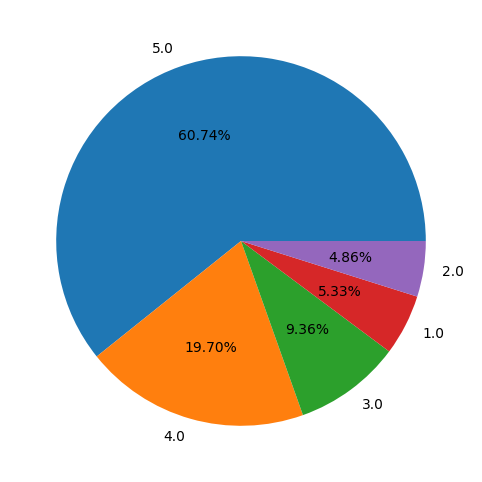

In [38]:
plt.figure(figsize=(8,6))
labels=amezon_df['rating'].value_counts().keys()
data=amezon_df['rating'].value_counts().values
plt.pie(data,labels=labels,autopct='%1.2f%%')
plt.show()

**fro the above we can say that the total 60+ percentage of review is 5 and the next is 4 whent the 19+**

In [39]:
amezon_df['text_']

,text_
0,"Love this! Well made, sturdy, and very comfor..."
1,"love it, a great upgrade from the original. I..."
2,This pillow saved my back. I love the look and...
3,"Missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...
...,...
40427,I had read some reviews saying that this bra r...
40428,I wasn't sure exactly what it would be. It is ...
40429,"You can wear the hood by itself, wear it with ..."
40430,I liked nothing about this dress. The only rea...


In [40]:
import string, nltk
from nltk import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [41]:

nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [42]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# creating function to cleaned the text

In [43]:
from nltk.corpus import stopwords
def clened_text(text):
  nopunc=[w for w in text if w not in string.punctuation]
  nopunc="".join(nopunc)
  return " ".join([word for word in nopunc.split() if word.lower() not in stopwords.words('english')])

In [44]:
amezon_df['text_'][0],clened_text(amezon_df['text_'][0])

('Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty',
 'Love Well made sturdy comfortable love itVery pretty')

In [45]:
amezon_df['clened_text']=amezon_df['text_'].apply(clened_text)

In [46]:
amezon_df['clened_text']

,clened_text
0,Love Well made sturdy comfortable love itVery ...
1,love great upgrade original Ive mine couple years
2,pillow saved back love look feel pillow
3,Missing information use great product price
4,nice set Good quality set two months
...,...
40427,read reviews saying bra ran small ordered TWO ...
40428,wasnt sure exactly would little large small si...
40429,wear hood wear hood wear jacket without hood 3...
40430,liked nothing dress reason gave 4 stars ordere...


In [47]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
def preprocess(text):
    return ' '.join([word for word in word_tokenize(text) if word not in stopwords.words('english') and not word.isdigit() and word not in string.punctuation])

In [49]:
preprocess(amezon_df['text_'][0]),amezon_df['text_'][0]


('Love Well made sturdy comfortable I love Very pretty',
 'Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty')

In [50]:
amezon_df['text_']

,text_
0,"Love this! Well made, sturdy, and very comfor..."
1,"love it, a great upgrade from the original. I..."
2,This pillow saved my back. I love the look and...
3,"Missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...
...,...
40427,I had read some reviews saying that this bra r...
40428,I wasn't sure exactly what it would be. It is ...
40429,"You can wear the hood by itself, wear it with ..."
40430,I liked nothing about this dress. The only rea...


In [51]:
amezon_df['clened_text']=amezon_df['text_'].apply(preprocess)

In [52]:
amezon_df['clened_text'].head()

,clened_text
0,Love Well made sturdy comfortable I love Very ...
1,love great upgrade original I 've mine couple ...
2,This pillow saved back I love look feel pillow
3,Missing information use great product price I
4,Very nice set Good quality We set two months


In [53]:
stemer=PorterStemmer()

In [54]:
def stemed_word(text):
  return " ".join([stemer.stem(word)  for word in text.split()])
amezon_df['clened_text']=amezon_df['clened_text'].apply(lambda x :stemed_word(x))

In [55]:
amezon_df['clened_text']


,clened_text
0,love well made sturdi comfort i love veri pretti
1,love great upgrad origin i 've mine coupl year
2,thi pillow save back i love look feel pillow
3,miss inform use great product price i
4,veri nice set good qualiti we set two month
...,...
40427,i read review say bra ran small i order two ba...
40428,i n't sure exactli would it littl larg small s...
40429,you wear hood wear hood wear jacket without ho...
40430,i like noth dress the reason i gave star i ord...


In [56]:
amezon_df.to_csv('clened_revivew.csv')

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, string
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [58]:
df=pd.read_csv('/content/clened_revivew.csv')

In [59]:
df.head()

,Unnamed: 0,category,rating,label,text_,clened_text
0,0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",love well made sturdi comfort i love veri pretti
1,1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",love great upgrad origin i 've mine coupl year
2,2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,thi pillow save back i love look feel pillow
3,3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",miss inform use great product price i
4,4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,veri nice set good qualiti we set two month


In [60]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [61]:
df.dropna(inplace=True)

In [62]:
df['length']=df['clened_text'].apply(len)

In [63]:
df['length']

,length
0,48
1,46
2,44
3,37
4,43
...,...
40427,1004
40428,731
40429,1249
40430,753


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40431 entries, 0 to 40431
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     40431 non-null  object 
 1   rating       40431 non-null  float64
 2   label        40431 non-null  object 
 3   text_        40431 non-null  object 
 4   clened_text  40431 non-null  object 
 5   length       40431 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 2.2+ MB


(array([6.4790e+03, 1.1011e+04, 5.6100e+03, 3.6930e+03, 2.5170e+03,
        1.7860e+03, 1.4500e+03, 1.1140e+03, 9.2200e+02, 8.1900e+02,
        6.4600e+02, 6.3800e+02, 5.6500e+02, 4.9100e+02, 4.6900e+02,
        3.7300e+02, 3.3900e+02, 2.7500e+02, 2.0700e+02, 1.9800e+02,
        1.7400e+02, 1.5500e+02, 1.3000e+02, 1.1200e+02, 7.4000e+01,
        5.4000e+01, 3.9000e+01, 3.4000e+01, 2.0000e+01, 1.3000e+01,
        8.0000e+00, 0.0000e+00, 4.0000e+00, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 3.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([   8.  ,   52.54,   97.08,  141.62,  186.16,  230.7 ,  275.24,
         319.78,  364.32,  408.86,  453.4 ,  497.94,  542.48,  587.02,
         631.56,  676.1 ,  720.64,  765.18,  809.72,  854.26,  898.8 ,
         943.34,  987.88, 1032.42, 1076.96, 1121.5 , 1166.04, 1210.58,
        1255.12, 1299.66, 1344.2 ,

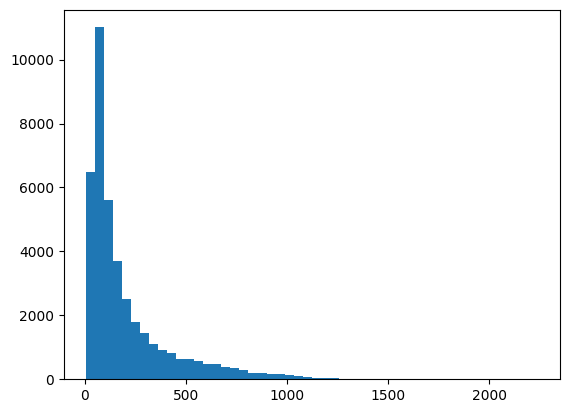

In [65]:
plt.hist(df['length'],bins=50)

In [66]:
df.groupby('label').describe()

rating                                                length  \
         count      mean       std  min  25%  50%  75%  max    count   
label                                                                  
CG     20215.0  4.259906  1.141092  1.0  4.0  5.0  5.0  5.0  20215.0   
OR     20216.0  4.253265  1.147652  1.0  4.0  5.0  5.0  5.0  20216.0   

                                                                 
             mean         std   min   25%    50%    75%     max  
label                                                            
CG     173.765570  174.093139  13.0  57.0   99.0  217.0  1300.0  
OR     238.198556  253.286565   8.0  74.0  134.0  297.0  2235.0

array([<Axes: title={'center': 'CG'}>, <Axes: title={'center': 'OR'}>],
      dtype=object)

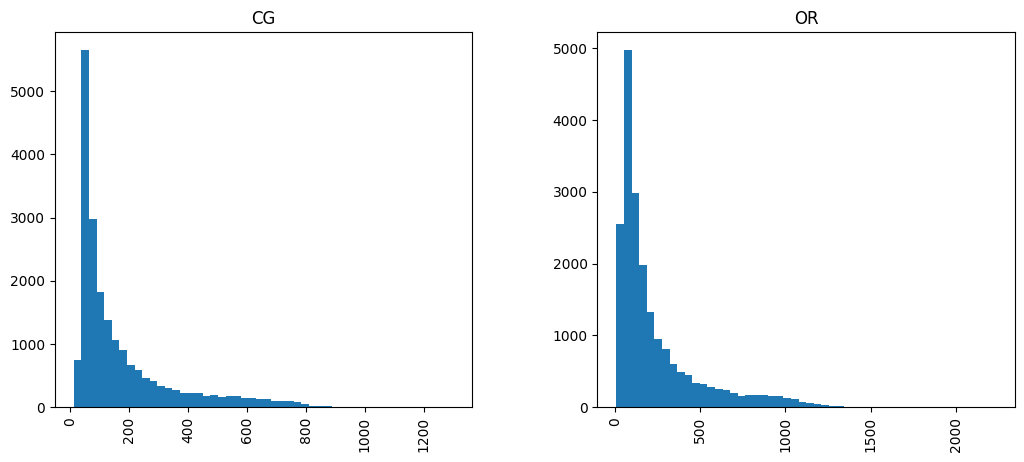

In [67]:
df.hist(column='length',by='label',figsize=(12,5),bins=50)

In [68]:
df[df['label']=='OR'][['clened_text','length']].sort_values(by='length',ascending=False).head().iloc[0].clened_text

"weak on current scienc after see twice i agre much posit five star review out respect read review i 'll repeat everyth i like present i found goofi overs ear hairdo facial hair arrang daniel vitali describ `` wild food expert '' distract ugh ditto david wolf extrem goofi wild hairdo on hand jon gabriel describ `` author weight loss expert '' nice groom good present hi stori person transform fellow pound whew becom jock normal weight inspir christian northrup preserv rank one america 's cutest doctor a realli nice look woman present dr. mercola jason vale kri carr alejandro junger fine it disappoint jami oliv popular uk give babi cow growth fluid pass unscientif popular idea milk none present anyth zilch say work doctor t. colin campbel milk bodi bad it good see present take stand sugar they agre evil sugar refin carbohydr with respect dr. northrup `` it 's fat make fat 's sugar '' statement pass muster commun expert recogn evil sugar not mutual exclus recogn proven danger fat particul

In [69]:
def text_process(review):
    nopunc = [char for char in review if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [70]:
bow_transformer=CountVectorizer(analyzer=text_process)
bow_transformer

CountVectorizer(analyzer=<function text_process at 0x7cf6dc17a840>)

In [71]:
print(bow_transformer)

CountVectorizer(analyzer=<function text_process at 0x7cf6dc17a840>)


In [72]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [73]:
bow_transformer.fit(df['clened_text'])


CountVectorizer(analyzer=<function text_process at 0x7cf6dc17a840>)

In [74]:
print(len(bow_transformer.vocabulary_))

34530


In [75]:
review4=df['clened_text'][4]
review4

'veri nice set good qualiti we set two month'

In [76]:
bow_msg=bow_transformer.transform([review4])
print(bow_msg)
print(bow_msg.shape)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 34530)>
  Coords	Values
  (0, 13408)	1
  (0, 20142)	1
  (0, 20952)	1
  (0, 24479)	1
  (0, 27036)	2
  (0, 31561)	1
  (0, 32489)	1
(1, 34530)


In [77]:
print(bow_transformer.get_feature_names_out()[13408])
print(bow_transformer.get_feature_names_out()[32489])

good
veri


In [78]:
bow_reviews=bow_transformer.transform(df['clened_text'])

In [79]:
print("Shape of Bag of Words Transformer for the entire reviews corpus:",bow_reviews.shape)
print("Amount of non zero values in the bag of words model:",bow_reviews.nnz)

Shape of Bag of Words Transformer for the entire reviews corpus: (40431, 34530)
Amount of non zero values in the bag of words model: 1014190


In [80]:
print("Sparsity:",np.round((bow_reviews.nnz/(bow_reviews.shape[0]*bow_reviews.shape[1]))*100,2))

Sparsity: 0.07


In [81]:
tfidf=tf=TfidfTransformer().fit(bow_reviews)
bow_rev4=tfidf.transform(bow_msg)
print(bow_msg)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 34530)>
  Coords	Values
  (0, 13408)	1
  (0, 20142)	1
  (0, 20952)	1
  (0, 24479)	1
  (0, 27036)	2
  (0, 31561)	1
  (0, 32489)	1


In [82]:
print(tfidf.idf_[bow_transformer.vocabulary_['mango']])
print(tfidf.idf_[bow_transformer.vocabulary_['book']])

10.91422964906803
2.821684385176731


In [83]:
tfidf_review=tfidf.transform(bow_reviews)
print(tfidf_review.shape,'shape')
print('number of dimentions ', tfidf_review.ndim)

(40431, 34530) shape
number of dimentions  2


In [84]:
X=df['clened_text']
y=df['label']

In [85]:
X,y

(0         love well made sturdi comfort i love veri pretti
 1           love great upgrad origin i 've mine coupl year
 2             thi pillow save back i love look feel pillow
 3                    miss inform use great product price i
 4              veri nice set good qualiti we set two month
                                ...                        
 40427    i read review say bra ran small i order two ba...
 40428    i n't sure exactli would it littl larg small s...
 40429    you wear hood wear hood wear jacket without ho...
 40430    i like noth dress the reason i gave star i ord...
 40431    i work wed industri work long day feet outsid ...
 Name: clened_text, Length: 40431, dtype: object,
 0        CG
 1        CG
 2        CG
 3        CG
 4        CG
          ..
 40427    OR
 40428    CG
 40429    OR
 40430    CG
 40431    OR
 Name: label, Length: 40431, dtype: object)

In [86]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.35,random_state=42)

In [87]:
pipeline_lr=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('classifier',MultinomialNB())
])

In [88]:
pipeline_lr.fit(x_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [89]:
y_pred=pipeline_lr.predict(x_test)

In [90]:
y_pred

array(['CG', 'CG', 'OR', ..., 'OR', 'CG', 'CG'], dtype='<U2')


##  Model Evaluation Metrics

The following metrics were used to evaluate model performance:

- Accuracy Score
- Confusion Matrix
- Precision
- Recall
- F1-Score
- Classification Report



In [91]:
print(f"classification_report { classification_report(y_test,y_pred)}")

classification_report               precision    recall  f1-score   support

          CG       0.82      0.89      0.85      7104
          OR       0.88      0.80      0.84      7047

    accuracy                           0.85     14151
   macro avg       0.85      0.85      0.85     14151
weighted avg       0.85      0.85      0.85     14151



In [92]:
print(f"thr confusion matix {confusion_matrix(y_test,y_pred)}")

thr confusion matix [[6354  750]
 [1407 5640]]


In [93]:
print(f" the accuracy of the model : {accuracy_score(y_test,y_pred)}")

 the accuracy of the model : 0.8475726097095612


# **Random Forest**

In [94]:
randomforesr_pipeline=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('classifire', RandomForestClassifier())
])

In [95]:
randomforesr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifire', RandomForestClassifier())])

In [96]:
y_pred2=randomforesr_pipeline.predict(x_test)

In [97]:
print(f"classification_report { classification_report(y_test,y_pred2)}")

classification_report               precision    recall  f1-score   support

          CG       0.84      0.90      0.87      7104
          OR       0.89      0.82      0.86      7047

    accuracy                           0.86     14151
   macro avg       0.86      0.86      0.86     14151
weighted avg       0.86      0.86      0.86     14151



In [98]:
print(f"thr confusion matix {confusion_matrix(y_test,y_pred2)}")

thr confusion matix [[6382  722]
 [1240 5807]]


In [99]:
print(f' accuracy score {accuracy_score(y_test,y_pred2)}')

 accuracy score 0.8613525545897817


In [100]:
from xgboost import XGBClassifier

In [101]:
x_pipepline=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('classifier',XGBClassifier())
])

In [102]:
x_pipepline.fit(x_train,y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['CG' 'OR']

In [103]:
y_change=y.replace('OR',1)
y_change=y_change.replace('CG',0)

In [104]:
y_change

,label
0,0
1,0
2,0
3,0
4,0
...,...
40427,1
40428,0
40429,1
40430,0


In [105]:
x_trainxg,x_testxg,y_trainxg,y_testxg=train_test_split(X,y_change,test_size=.25,random_state=42)

In [106]:
y_testxg

,label
27957,0
39755,0
24983,1
13985,0
39275,1
...,...
31033,1
31001,1
29601,0
38580,1


In [107]:
x_pipepline.fit(x_trainxg,y_trainxg)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [108]:
y_pred3=x_pipepline.predict(x_testxg)

In [109]:
print(accuracy_score(y_testxg,y_pred3))

0.8576375148397309


In [110]:
print(classification_report(y_testxg,y_pred3))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      5041
           1       0.85      0.87      0.86      5067

    accuracy                           0.86     10108
   macro avg       0.86      0.86      0.86     10108
weighted avg       0.86      0.86      0.86     10108



In [111]:
print(confusion_matrix(y_testxg,y_pred3))

[[4239  802]
 [ 637 4430]]


In [112]:
from sklearn.svm import SVC


In [113]:
from sklearn.pipeline import Pipeline
svm_pipeline=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('svc',SVC(probability=True))
])

In [114]:
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('svc', SVC(probability=True))])

In [115]:
y_pred4=svm_pipeline.predict(x_test)

In [116]:
print(f" the confusion matix {confusion_matrix(y_test,y_pred4)}")

 the confusion matix [[6147  957]
 [ 573 6474]]


In [117]:
print(f" the classifcation report {classification_report(y_test,y_pred4)}")

 the classifcation report               precision    recall  f1-score   support

          CG       0.91      0.87      0.89      7104
          OR       0.87      0.92      0.89      7047

    accuracy                           0.89     14151
   macro avg       0.89      0.89      0.89     14151
weighted avg       0.89      0.89      0.89     14151



In [118]:
print(f"the accuracy score : {accuracy_score(y_test,y_pred4)}")

the accuracy score : 0.8918804324782701


In [119]:
from sklearn.linear_model import LogisticRegression
lR_pipeline=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('classifier',LogisticRegression())
])

In [120]:
lR_pipeline.fit(x_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', LogisticRegression())])

In [121]:
y_pred5=lR_pipeline.predict(x_test)

In [122]:
print(f" the confusion matix {confusion_matrix(y_test,y_pred5)}")
print(f" the classifcation report {classification_report(y_test,y_pred5)}")
print(f"accuracy score {accuracy_score(y_test,y_pred5)}")

 the confusion matix [[6065 1039]
 [ 697 6350]]
 the classifcation report               precision    recall  f1-score   support

          CG       0.90      0.85      0.87      7104
          OR       0.86      0.90      0.88      7047

    accuracy                           0.88     14151
   macro avg       0.88      0.88      0.88     14151
weighted avg       0.88      0.88      0.88     14151

accuracy score 0.8773231573740372


# **observation**






In [123]:
print(f"the accuracy of the logistic regression {accuracy_score(y_test,y_pred5)}")
print(f"the accuracy of the random forest {accuracy_score(y_test,y_pred2)}")
print(f"the  accuracu of the Xg boost {accuracy_score(y_testxg,y_pred3)}")
print(f"the accuracy of the svm { accuracy_score(y_test,y_pred4)}")

the accuracy of the logistic regression 0.8773231573740372
the accuracy of the random forest 0.8613525545897817
the  accuracu of the Xg boost 0.8576375148397309
the accuracy of the svm 0.8918804324782701


In [124]:
import pickle as pkl


## Ensemble Learning

To improve overall performance, a Voting Classifier was created by combining multiple machine learning models.

### Ensemble Models
- Logistic Regression
- Random Forest
- XGBoost
- SVM

Voting techniques used:
- Hard Voting
- Soft Voting


In [125]:
from sklearn.ensemble import VotingClassifier

In [126]:
rf=randomforesr_pipeline
lr=lR_pipeline
xgb=x_pipepline
svm=svm_pipeline
lr=pipeline_lr

In [129]:
ensebler=VotingClassifier(
    estimators=[('lr',lr),('rf',rf),('svm',svm)],
    voting='soft'
)

In [130]:
ensebler.fit(x_train,y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('bow', CountVectorizer()),
                                              ('tfidf', TfidfTransformer()),
                                              ('classifier',
                                               MultinomialNB())])),
                             ('rf',
                              Pipeline(steps=[('bow', CountVectorizer()),
                                              ('tfidf', TfidfTransformer()),
                                              ('classifire',
                                               RandomForestClassifier())])),
                             ('svm',
                              Pipeline(steps=[('bow', CountVectorizer()),
                                              ('tfidf', TfidfTransformer()),
                                              ('svc',
                                               SVC(probability=True))]))],
                 voting='soft')

In [ ]:
ensebler=VotingClassifier(
    estimators=[('lr',lr),('rf',rf),('xgb',xgb),],
    voting='hard' # Changed to 'hard' voting
)
ensebler.fit(x_train,y_train)
y_pred_ensebler=ensebler.predict(x_test)

In [ ]:
acuu=accuracy_score(y_test,y_pred_ensebler)

In [ ]:
acuu

In [131]:
soft_pred=ensebler.predict(x_test)

In [132]:
accuracy_score(y_test,soft_pred)

0.8927284290862837

##  Model Saving

The trained models were saved using Pickle for future deployment.

Saved files include:

- `esambler_review.pkl`
- `bow_vectirazation.pkl`
- `tfidf_transformer.pkl`


In [133]:
import pickle as pkl

In [136]:
with open ('esambler_review.pkl','wb')as f:
  pkl.dump(ensebler,f)

In [139]:
with open ('bow_vectirazation.pkl','wb') as f:
  pkl.dump(CountVectorizer,f)

In [140]:
with open ('tfidf_transformer.pkl','wb') as f:
  pkl.dump(TfidfTransformer,f)

##  Future Improvements

- Deep Learning (LSTM, GRU)
- BERT-based Fake Review Detection
- Real-Time Review Monitoring
- Explainable AI (XAI)
- Interactive Dashboard using Plotly

##  Expected Outcome

The final system can automatically analyze review text and determine whether a review is genuine or deceptive, helping customers make informed decisions and businesses maintain trust.

